# __Foci Detection Project__

This notebook goes through all the necessary steps to detect DNA damage in cell nuclei, called Foci.

1. __Dataset Exploration:__ Examining the dataset, visualizing images, and analyzing their properties
2. __Data Preprocessing:__ Setting up preprocessing pipelines
3. __Process Images:__ Setting up a region growing workflow to detect cell nuclei in images.



In [ ]:
import matplotlib.pyplot as plt
import random
from pathlib import Path
from PIL import Image

example_folder = Path('data/Ex 3 day 01')
blue_img = next(example_folder.glob("*Blue.tif"))
red_img = next(example_folder.glob("*Red.tif"))


## Sample 6 random Images to visualize

In [ ]:
'''sampled_folders = random.sample(experiment_folders, 6)

plt.figure(figsize=(12, 8))

for i, folder in enumerate(sampled_folders, 1):
    try:
        blue_path = next(folder.glob('*Blue.tif'))
        img = Image.open(blue_path)
        plt.subplot(2, 3, i)
        plt.imshow(img)
        plt.axis("off")
        plt.title(folder.name)

    except StopIteration:
        print(f"No blue channel found in {folder.name}.")

plt.tight_layout()
plt.show()'''

'sampled_folders = random.sample(experiment_folders, 6)\n\nplt.figure(figsize=(12, 8))\n\nfor i, folder in enumerate(sampled_folders, 1):\n    try:\n        blue_path = next(folder.glob(\'*Blue.tif\'))\n        img = Image.open(blue_path)\n        plt.subplot(2, 3, i)\n        plt.imshow(img)\n        plt.axis("off")\n        plt.title(folder.name)\n\n    except StopIteration:\n        print(f"No blue channel found in {folder.name}.")\n\nplt.tight_layout()\nplt.show()'

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import math
from pathlib import Path

'''def plot_individual_histograms(experiment_folders, color_suffix="Blue"):
    num_imgs = len(experiment_folders)
    cols = 3
    rows = math.ceil(num_imgs / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))

    if num_imgs == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    for i, folder_path in enumerate(experiment_folders):
        try:
            img_path = next(folder_path.glob(f"*{color_suffix}.tif"))

            img = Image.open(img_path).convert("L")
            pixels = np.array(img).ravel()

            axes[i].hist(pixels, bins=256, color='gray', range=(0, 255), log=True)
            axes[i].set_title(f"{folder_path.name}")
            axes[i].set_xlabel("Intensity")
            axes[i].set_ylabel("Frequency (Log)")
            axes[i].set_xlim(0, 255)

        except StopIteration:
            axes[i].text(0.5, 0.5, f"No {color_suffix} image\nfound in folder",
                         ha='center', va='center')
            axes[i].set_title(f"Missing: {folder_path.name}")

    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

plot_individual_histograms(sampled_folders, color_suffix="Blue") '''


'def plot_individual_histograms(experiment_folders, color_suffix="Blue"):\n    num_imgs = len(experiment_folders)\n    cols = 3\n    rows = math.ceil(num_imgs / cols)\n\n    fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))\n\n    if num_imgs == 1:\n        axes = [axes]\n    else:\n        axes = axes.flatten()\n\n    for i, folder_path in enumerate(experiment_folders):\n        try:\n            img_path = next(folder_path.glob(f"*{color_suffix}.tif"))\n\n            img = Image.open(img_path).convert("L")\n            pixels = np.array(img).ravel()\n\n            axes[i].hist(pixels, bins=256, color=\'gray\', range=(0, 255), log=True)\n            axes[i].set_title(f"{folder_path.name}")\n            axes[i].set_xlabel("Intensity")\n            axes[i].set_ylabel("Frequency (Log)")\n            axes[i].set_xlim(0, 255)\n\n        except StopIteration:\n            axes[i].text(0.5, 0.5, f"No {color_suffix} image\nfound in folder",\n                         ha=\'center\', 

As we can see, the nuclei vary in count, size and intensitiy. This creates some challanges:
- Wide variation in nucleus size (tiny to very large) makes fixed-scale detection unreliable.
- Large differences in intensity and contrast hinder thresholding and consistent segmentation.
- Variable cell density causes problems in both sparse and highly crowded regions.
- Overlapping or touching nuclei make instance separation difficult.
- Shape variability (round, elongated, irregular, fragmented) breaks shape-based assumptions.
- Noise, artifacts, and uneven illumination can mimic nuclei or obscure true ones.
- Staining variability across experiments or labs reduces model generalization.
- Domain shifts between microscopes, magnifications, or imaging protocols.
- Low contrast nuclei blend into the background.
- Ambiguous boundaries due to blur or imaging limitations.
- Limited or inconsistent annotations, especially in dense clusters.
- Scale changes between datasets (different pixel sizes or resolutions).

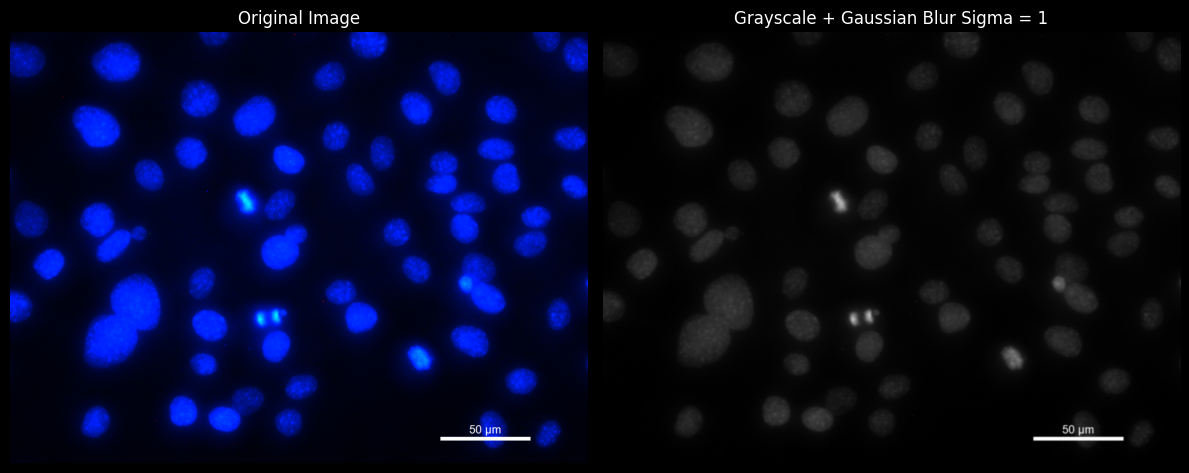

In [ ]:
# Data Preprocessing
#- Grayscale
#- Gaussian blurr

import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from skimage import io, filters, measure, color

original_image = io.imread(blue_img)

# Grayscale Conversion
if original_image.ndim == 3:
    # This result is a 2D float array (0.0 to 1.0)
    grayscale_image = color.rgb2gray(original_image)
else:
    # If the image is already 2D (grayscale), use it directly
    grayscale_image = original_image

# Gaussian Blur
blurred_image = filters.gaussian(grayscale_image, sigma=1)


# Create figure with 1 row and 2 columns
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

#Original Image
# Use cmap=None for color images, 'gray' for 2D images
axes[0].imshow(original_image, cmap=None if original_image.ndim == 3 else 'gray')
axes[0].set_title('Original Image')
axes[0].axis('off')

#Blurred Grayscale Image
axes[1].imshow(blurred_image, cmap='gray')
axes[1].set_title('Grayscale + Gaussian Blur Sigma = 1')
axes[1].axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## Li Thresholding and Initial Area Analysis


Detected Blobs (incl. Noise): 62

--- Blob Area Statistics (Pre-Filter) ---
Total Blobs: 62
Min Area: 1.0, Max Area: 26496.0, Average Area: 4795.19


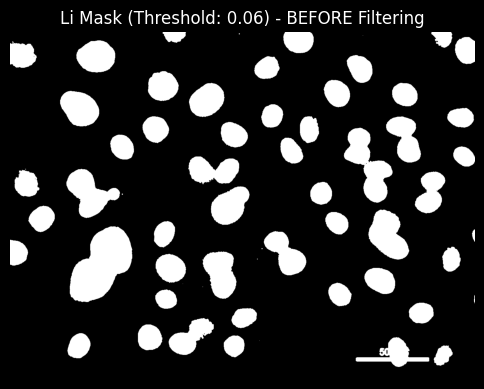

In [ ]:
from skimage.measure import label, regionprops

def analyze_cell_sizes(li_mask):

    labeled_li = label(li_mask)

    # regionprops gibt die Eigenschaften jeder Region
    li_props = regionprops(labeled_li) # Corrected variable name from auto_li to li_props

    print(f"Detected Blobs (incl. Noise): {len(li_props)}")

    #Extract cell size
    li_areas = [r.area for r in li_props]

    if not li_areas:
        print("No areas detected. Analysis stopped.")
        return [], 0


    print("\n--- Blob Area Statistics (Pre-Filter) ---")
    print(f"Total Blobs: {len(li_areas)}")
    print(f"Min Area: {np.min(li_areas)}, Max Area: {np.max(li_areas)}, Average Area: {np.mean(li_areas):.2f}")

    return li_props, np.mean(li_areas) #Return properties and median for filtering


#Apply Li Threshold
li_threshold_value = filters.threshold_li(blurred_image)
li_mask_initial = blurred_image > li_threshold_value

#Analyze the initial mask
all_li_props, average_area = analyze_cell_sizes(li_mask_initial)

#Visualize the initial mask
plt.figure(figsize=(6, 6))
plt.imshow(li_mask_initial, cmap='gray')
plt.title(f"Li Mask (Threshold: {li_threshold_value:.2f}) - BEFORE Filtering")
plt.axis('off')
plt.show()

## Noise Filtering


Average Area: 4795.19. Minimum Size Filter applied: 3116.75 pixels

--- Final Filtered Results ---
Objects Remaining (Cells): 43
Total Area Remaining: 278537.0


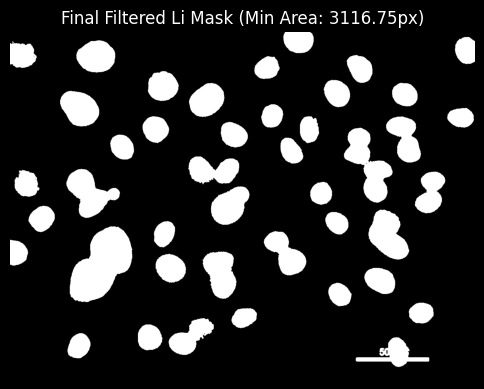

In [ ]:
from skimage import morphology

if 'average_area' in locals() and average_area > 0:
    # Set the filter threshold: Use a fraction of the median area to define noise.
    # We choose 10% of the median area as the minimum size to keep.
    # inspect the area statistics from Cell 2 and adjust this '0.1' factor if needed
    min_size_threshold = int(average_area)*0.65 #ToDo: Find ideal cut off

    print(f"Average Area: {average_area:.2f}. Minimum Size Filter applied: {min_size_threshold} pixels")

    #Remove noise
    li_mask_filtered = morphology.remove_small_objects(
        li_mask_initial.astype(bool),
        min_size=min_size_threshold
    )

    #analysis of filtered regions
    labeled_final = label(li_mask_filtered)
    final_props = regionprops(labeled_final)

    print(f"\n--- Final Filtered Results ---")
    print(f"Objects Remaining (Cells): {len(final_props)}")
    print(f"Total Area Remaining: {sum([r.area for r in final_props])}")

    plt.figure(figsize=(6, 6))
    plt.imshow(li_mask_filtered, cmap='gray')
    plt.title(f"Final Filtered Li Mask (Min Area: {min_size_threshold}px)")
    plt.axis('off')
    plt.show()

else:
    print("Filtering skipped: No objects detected or median area is zero.")

In [ ]:
#ToDo: Crop the my marker off, either black box or cut off

## Watershed Segemntation


--- Blob Area Statistics (Pre-Filter) ---
Total Blobs: 62
Min Area: 200.0, Max Area: 13688.0, Average Area: 4492.53


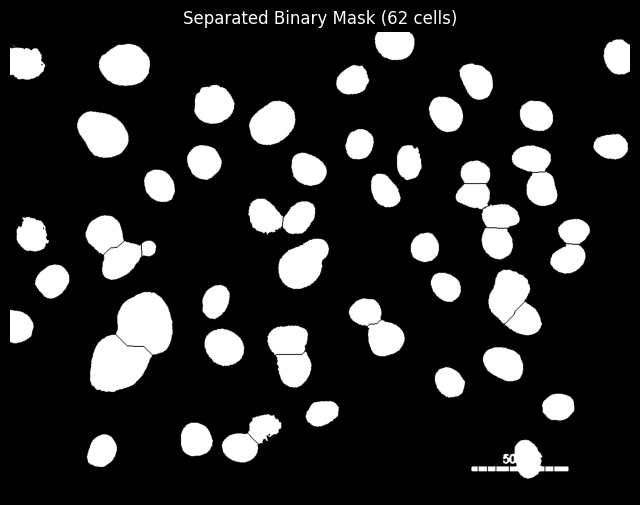

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage as sho
from skimage import feature, segmentation, measure
from skimage.segmentation import find_boundaries

def get_separated_binary_mask(binary_mask, min_distance=20):
    """
    Splits clumped cells from an EXISTING binary mask and returns stats.
    """
    # 1. Skip Thresholding (You already have a binary mask)
    # Ensure it's in a format the distance transform likes (0 and 1)
    binary_mask = binary_mask.astype(bool)

    # 2. Watershed Segmentation
    # Distance transform finds the 'centers' of the white blobs
    distance = sho.distance_transform_edt(binary_mask)

    # Identify local peaks
    coords = feature.peak_local_max(distance, min_distance=min_distance, labels=binary_mask)

    if len(coords) == 0:
        print("No peaks found. Check your min_distance or mask.")
        return binary_mask, np.zeros_like(binary_mask), []

    mask_seeds = np.zeros(distance.shape, dtype=bool)
    mask_seeds[tuple(coords.T)] = True
    markers, _ = sho.label(mask_seeds)

    # Watershed uses the inverse distance to find boundaries
    labeled_cells = segmentation.watershed(-distance, markers, mask=binary_mask)

    # 3. Generate Stats (Pre-Filter)
    props = measure.regionprops(labeled_cells)
    areas = [r.area for r in props]

    print("\n--- Blob Area Statistics (Pre-Filter) ---")
    print(f"Total Blobs: {len(areas)}")
    if areas:
        print(f"Min Area: {np.min(areas):.1f}, Max Area: {np.max(areas):.1f}, Average Area: {np.mean(areas):.2f}")
    else:
        print("No areas detected.")

    # 4. Create the final separated binary mask
    boundaries = find_boundaries(labeled_cells, mode='thick')

    final_binary_mask = binary_mask.copy()
    final_binary_mask[boundaries] = 0 # Cut the connections between cells

    return final_binary_mask, labeled_cells, areas

# --- Execution ---
# Pass the ALREADY thresholded/filtered mask here
separated_mask, labels, initial_areas = get_separated_binary_mask(li_mask_filtered, min_distance=20)

# --- Visualization ---
plt.figure(figsize=(8, 8))
plt.imshow(separated_mask, cmap='gray')
plt.title(f"Separated Binary Mask ({len(initial_areas)} cells)")
plt.axis('off')
plt.show()

#### Setup, Load Image, and Pre-Processing (Local Normalization) of Red Channel Image

Mean of Z-Score: -0.02967694002324037


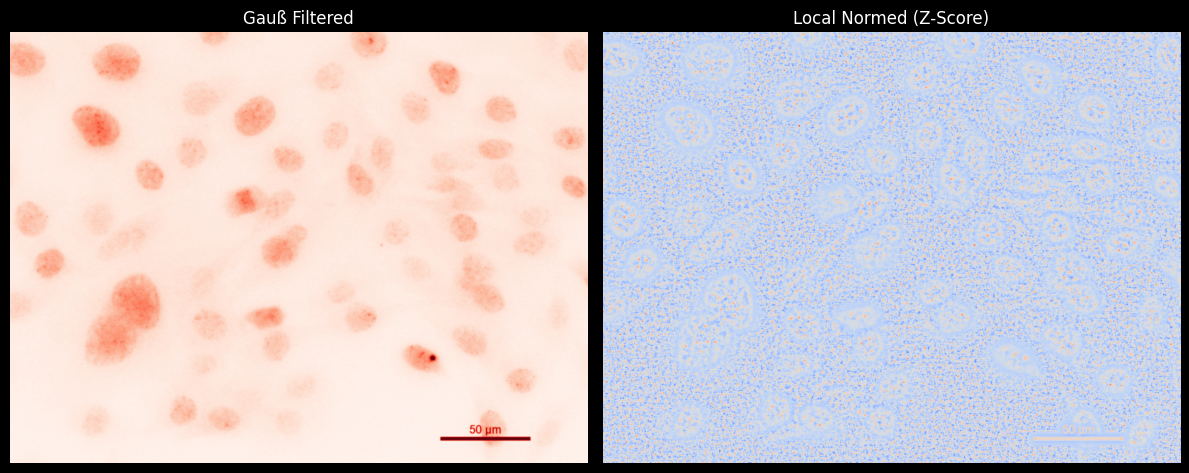

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from skimage import io, filters, measure, color
from skimage.filters import rank
from scipy import ndimage


IMAGE_PATH = red_img
WINDOW_SIZE = 21 #ToDo: Find optimal WS
EPSILON = 1e-6


def load_red_channel(path):
    image = io.imread(path)

    if image.ndim == 3:
        #conversion to 8-Bit
        return (image[:, :, 0]).astype(np.uint8)
    elif image.ndim == 2:
         return image.astype(np.uint8)
    else:
        raise ValueError("Image must be 2D (grayscale) or 3D (color).")

def preprocess_and_normalize(img_red_raw, window_size, epsilon):

    #Apply Gauß filter
    #Sigma=1 is a little bit of smoothing
    img_red_smoothed = filters.gaussian(img_red_raw, sigma=1) #ToDo: Find optimal sigma (ROC Curve)

    #local average and standard deviation
    local_mean = ndimage.uniform_filter(img_red_smoothed, size=window_size)
    local_std = np.sqrt(ndimage.uniform_filter(img_red_smoothed**2, size=window_size) - local_mean**2)

    #Z-Score Normierung: (Pixel - lokaler Mittelwert) / (lokale Standardabweichung + Epsilon)
    img_red_norm = (img_red_smoothed - local_mean) / (local_std + epsilon)

    return img_red_norm, img_red_smoothed

try:
    img_red_raw = load_red_channel(IMAGE_PATH)
    img_red_norm, img_red_smoothed = preprocess_and_normalize(img_red_raw, WINDOW_SIZE, EPSILON)


    fig, axs = plt.subplots(1, 2, figsize=(12, 5))

    axs[0].imshow(img_red_smoothed, cmap='Reds')
    axs[0].set_title("Gauß Filtered")
    axs[0].axis('off')

    axs[1].imshow(img_red_norm, cmap='coolwarm')
    axs[1].set_title("Local Normed (Z-Score)")
    axs[1].axis('off')

    print(f"Mean of Z-Score: {np.mean(img_red_norm)}")
    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"Fehler beim Laden/Verarbeiten des Bildes: {e}. Bitte Pfad prüfen.")

#### Masked Visualization after Blur in Red

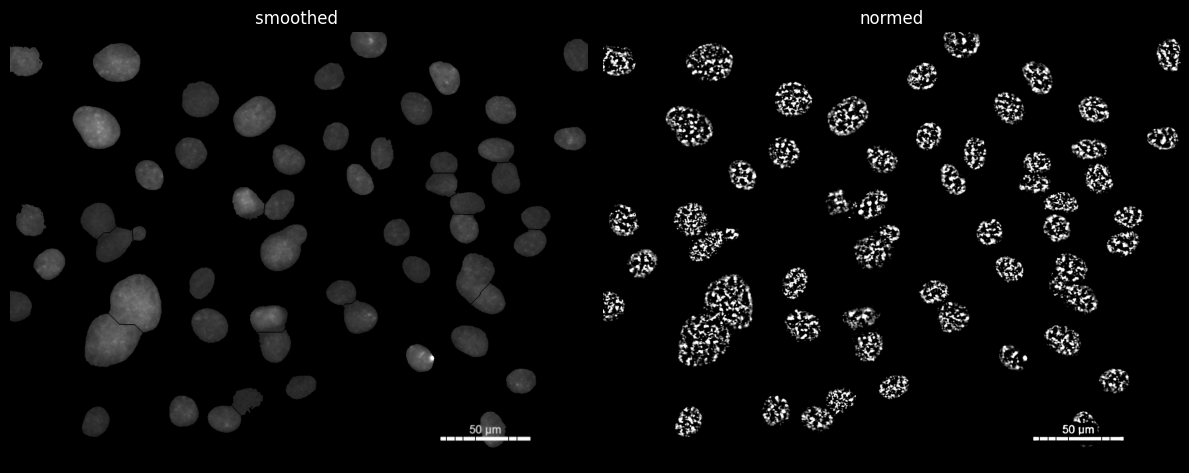

In [ ]:
smoothed_intensity = img_red_smoothed.astype(np.float32)
normed_intensity = img_red_norm.astype(np.float32)

# Black out the background (where li_mask_filtered = False)
masked_smooth = smoothed_intensity * separated_mask
masked_normed = normed_intensity * separated_mask

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

axs[0].imshow(masked_smooth, cmap='gray', vmin=0, vmax=1)
axs[0].set_title(f"smoothed ")
axs[0].axis('off')

axs[1].imshow(masked_normed, cmap='gray', vmin=0, vmax=1)
axs[1].set_title(f"normed")
axs[1].axis('off')

plt.tight_layout()
plt.show()

## ------ Foci Detection ------

Total Cells: 63
Total Foci: 241
   peak_id  global_x  global_y  intensity_mean  intensity_peak  \
0        1       869        22            0.47        0.556986   
1        2       859         0            0.36        0.417282   

   foci_radius_pixels  foci_area_approx  cell_area  
0                6.13        117.980003       4909  
1                2.83         25.129999       4909  


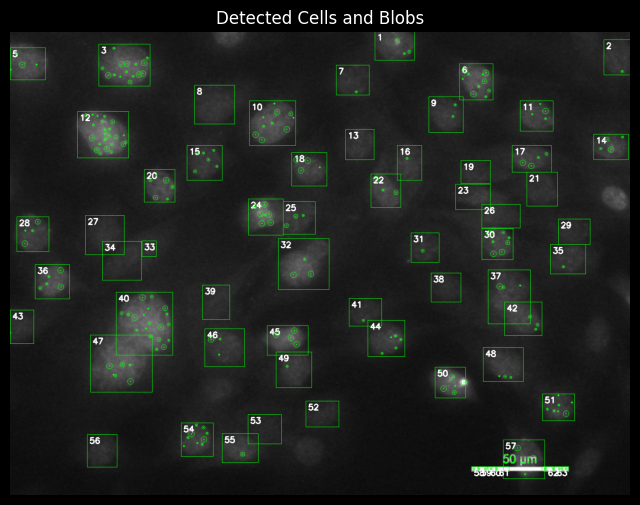

In [ ]:
import numpy as np
import cv2
import pandas as pd
from skimage import io, measure, feature
import matplotlib.pyplot as plt
from skimage.draw import disk

#Find Cells

cell_mask = masked_smooth > 0
labeled_cells = measure.label(cell_mask)
regions = measure.regionprops(labeled_cells, smoothed_intensity)

intensity_image_uint8 = (smoothed_intensity * 255).astype(np.uint8)
output_image = cv2.cvtColor(intensity_image_uint8, cv2.COLOR_GRAY2BGR)
foci_records = []
peak_id_counter = 1

#Annotation and Foci Detection Loop
for region in regions:
    #Skip tiny noise
    if region.area < 50:
        continue

    #Get cell bounding box (row min/max, col min/max)
    minr, minc, maxr, maxc = region.bbox

    #Draw Cell Bounding Box (Green)
    cv2.rectangle(output_image, (minc, minr), (maxc, maxr), (0, 255, 0), 1)

    #Add Cell Label
    cv2.putText(output_image, str(region.label), (minc + 5, minr + 20),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)

    #Extract the local intensity data for the current cell region
    cropped_intensity = smoothed_intensity[minr:maxr, minc:maxc]

    #Blob Detection --- Laplacian of Gaussian
    #Find bright blobs and estimate their size (sigma)
    #The returned array is [row, column, sigma]
    blobs_log = feature.blob_log(
        cropped_intensity,
        min_sigma=2,    #Smallest expected focus size (size in pixels) ToDo: Find optimal parameters
        max_sigma=5,   #Largest expected focus size
        num_sigma=10,
        threshold=0.03   #Lower threshold detects fainter foci; between 0 and 1 ToDo: Potenzial für ML
    )

    #Convert sigma to radius (radius = sigma * sqrt(2))
    blobs_log[:, 2] = blobs_log[:, 2] * np.sqrt(2)

    #Annotate and Record Foci
    for local_r, local_c, radius in blobs_log:
        local_r, local_c = int(local_r), int(local_c)

        # Convert local coordinates back to global image coordinates
        global_r = minr + local_r
        global_c = minc + local_c

        # Check if the blob center is actually inside the segmented cell mask
        if labeled_cells[global_r, global_c] != region.label:
            continue

        #Annotation: Center
        cv2.circle(output_image, (global_c, global_r), 1, (0, 255, 0), -1)

        #Annotation: estimated radius
        cv2.circle(output_image, (global_c, global_r), int(radius), (0, 255, 0), 1)

        #Use the calculated radius to define the focus area
        focus_radius = int(round(radius))

        #Create coordinates for the focus disk centered at (global_r, global_c)
        rr, cc = disk((global_r, global_c), focus_radius, shape=smoothed_intensity.shape)

        #Extract the intensities from the image that fall within the disk coordinates
        focus_intensities = smoothed_intensity[rr, cc]

        #Calculate the mean intensity over the focus area
        intensity_mean = np.mean(focus_intensities)

        #Data Collection
        foci_records.append({
            "peak_id": peak_id_counter,
            "global_x": global_c,
            "global_y": global_r,
            "intensity_mean": round(intensity_mean, 2),
            "intensity_peak": smoothed_intensity[global_r, global_c],
            "foci_radius_pixels": round(radius, 2),
            "foci_area_approx": round(np.pi * (radius**2), 2),
            "cell_area": round(region.area),
        })
        peak_id_counter += 1

#Convert Records to DataFrame
df = pd.DataFrame(foci_records)
csv_path = "output/cell_foci_log_analysis.csv"
df.to_csv(csv_path, index=False)

print(f"Total Cells: {len(regions)}")
print(f"Total Foci: {len(foci_records)}")
print(df.head(2))

plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(output_image, cv2.COLOR_BGR2RGB))
plt.title(f"Detected Cells and Blobs")
plt.axis("off")
plt.show()

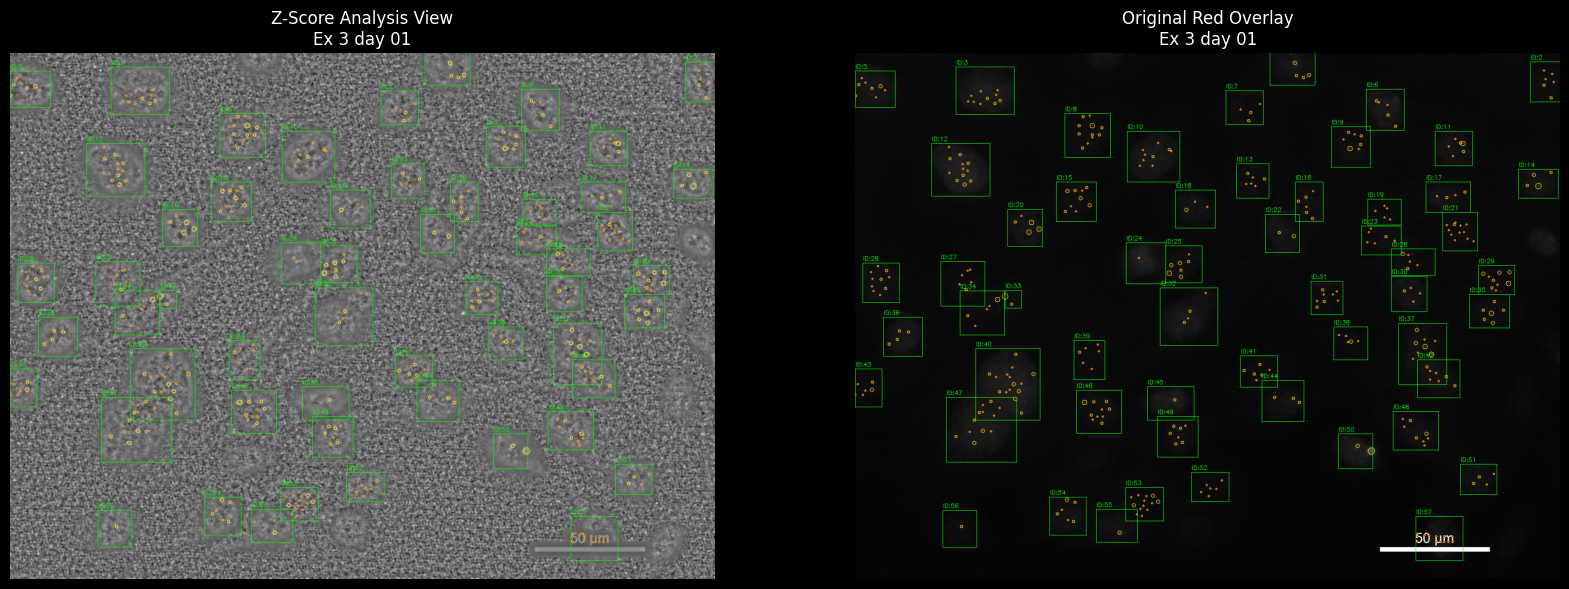

Successfully saved to data\Ex 3 day 01


In [ ]:
import numpy as np
import cv2
import pandas as pd
from skimage import measure, feature
import matplotlib.pyplot as plt
from skimage.draw import disk
from pathlib import Path
from PIL import Image

smoothed_intensity = img_red_norm.astype(np.float32)
cell_mask = masked_smooth > 0
labeled_cells = measure.label(cell_mask)
regions = measure.regionprops(labeled_cells, intensity_image=smoothed_intensity)


disp_z = ((smoothed_intensity - smoothed_intensity.min()) /
          (smoothed_intensity.max() - smoothed_intensity.min()) * 255).astype(np.uint8)
out_z = cv2.cvtColor(disp_z, cv2.COLOR_GRAY2BGR)

red_img_path = next(example_folder.glob("*Red.tif"))
img_red_orig = np.array(Image.open(red_img_path).convert("L"))
disp_orig = ((img_red_orig - img_red_orig.min()) /
             (img_red_orig.max() - img_red_orig.min()) * 255).astype(np.uint8)
out_orig = cv2.cvtColor(disp_orig, cv2.COLOR_GRAY2BGR)

foci_records = []
peak_id_counter = 1
folder_name = example_folder.name

#Analysis loop
for region in regions:
    if region.area < 50: continue

    cell_avg_intensity = region.mean_intensity
    minr, minc, maxr, maxc = region.bbox
    cropped_intensity = smoothed_intensity[minr:maxr, minc:maxc]

    blobs_log = feature.blob_log(cropped_intensity, min_sigma=2, max_sigma=5, num_sigma=10, threshold=1)

    if len(blobs_log) == 0: continue

    for img in [out_z, out_orig]:
        cv2.rectangle(img, (minc, minr), (maxc, maxr), (0, 255, 0), 1)
        cv2.putText(img, f"ID:{region.label}", (minc, minr - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 255, 0), 1)

    for local_r, local_c, sigma in blobs_log:
        local_r, local_c = int(local_r), int(local_c)
        global_r, global_c = minr + local_r, minc + local_c

        if labeled_cells[global_r, global_c] != region.label: continue

        intensity_at_peak = smoothed_intensity[global_r, global_c]

        if intensity_at_peak > cell_avg_intensity:
            radius = sigma * np.sqrt(2)

            for img in [out_z, out_orig]:
                cv2.circle(img, (global_c, global_r), int(radius), (0, 255, 255), 1) #Circumference of Foci
                cv2.circle(img, (global_c, global_r), 1, (0, 0, 255), -1)           #Center of Foci

            rr, cc = disk((global_r, global_c), max(1, int(radius)), shape=smoothed_intensity.shape)
            focus_mean_intensity = np.mean(smoothed_intensity[rr, cc])

            foci_records.append({
                "cell_id": region.label,
                "peak_id": peak_id_counter,
                "cell_intensity_mean": round(cell_avg_intensity, 4),
                "foci_intensity_peak": round(intensity_at_peak, 4),
                "foci_radius": round(radius, 2),
                "signal_to_cell_ratio": round(intensity_at_peak / cell_avg_intensity, 2),
                "foci_x": global_c,
                "foci_y": global_r
            })
            peak_id_counter += 1

df = pd.DataFrame(foci_records)

fig, ax = plt.subplots(1, 2, figsize=(20, 10))

ax[0].imshow(cv2.cvtColor(out_z, cv2.COLOR_BGR2RGB))
ax[0].set_title(f"Z-Score Analysis View\n{folder_name}")
ax[0].axis("off")

ax[1].imshow(cv2.cvtColor(out_orig, cv2.COLOR_BGR2RGB))
ax[1].set_title(f"Original Red Overlay\n{folder_name}")
ax[1].axis("off")

path_csv = example_folder / "foci_analysis.csv"
path_img_combined = example_folder / "foci_comparison.png"

try:
    path_csv.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(path_csv, index=False)
    plt.savefig(path_img_combined, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Successfully saved to {example_folder}")
except Exception as e:
    print(f"Error while saving {e}")

    #ToDo: Slap the detections onto an RGB Image ; no idea how to